In [33]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import norm
import ast
import matplotlib.pyplot as plt
import forestplot as fp
from scipy import stats

In [34]:
input_df = pd.read_csv('IVW_w_baseline.tsv', sep='\t')

In [35]:
egfr_baseline = pd.read_csv('ivw_egfr_baseline.tsv', sep='\t')
egfr_prism = pd.read_csv('ivw_egfr_prism.tsv', sep='\t')
egfr_baseline['model'] = 'baseline'
egfr_prism['model'] = 'tissue-specific'

In [36]:
input_df = input_df[~input_df['trait'].str.startswith('eGFR')]

In [37]:
input_df = pd.concat([input_df, egfr_prism, egfr_baseline])

In [38]:
input_df = input_df.drop(columns=['short_name', 'cohort'])

In [39]:
input_df 

,eval,l_eval,u_eval,q,q_df,q_pval,n,k,trait,model
0,0.010688,0.008013,0.013362,0.271331,2,0.873135,22445.0,3,Lymphocyte_count,tissue-specific
1,0.046243,0.016113,0.076372,0.000000,0,1.000000,705.0,1,FEV1_FVC,tissue-specific
2,0.033948,0.029398,0.038497,0.785760,2,0.675110,23497.0,3,LDL_C,tissue-specific
3,0.009459,0.006939,0.011978,0.498772,2,0.779279,22445.0,3,Lymphocyte_count,baseline
4,0.042439,0.013461,0.071418,0.000000,0,1.000000,705.0,1,FEV1_FVC,baseline
5,0.031657,0.027254,0.036061,0.181705,2,0.913152,23497.0,3,LDL_C,baseline
0,0.001106,-0.000887,0.003098,3.849093,2,0.145942,4218.0,3,eGFR (Core),tissue-specific
1,0.000726,-0.000294,0.001746,4.218885,6,0.647082,10626.0,7,eGFR (Comprehensive),tissue-specific
0,0.001828,-0.000732,0.004388,3.875811,2,0.144005,4218.0,3,eGFR (Core),baseline
1,0.000848,-0.000254,0.001949,5.084142,6,0.533067,10626.0,7,eGFR (Comprehensive),baseline


In [40]:
input_df["eval_fmt"] = input_df["eval"].map(lambda x: f"{x:.4f}")
input_df["l_eval_fmt"] = input_df["l_eval"].map(lambda x: f"{x:.4f}")
input_df["u_eval_fmt"] = input_df["u_eval"].map(lambda x: f"{x:.4f}")

In [41]:
input_df["r2_ci"] = input_df.apply(
    lambda row: f'{row["eval"]:.4f} [{row["l_eval"]:.4f}, {row["u_eval"]:.4f}]',
    axis=1
)

In [42]:
input_df["n_fmt"] = input_df["n"].astype(int).astype(str)

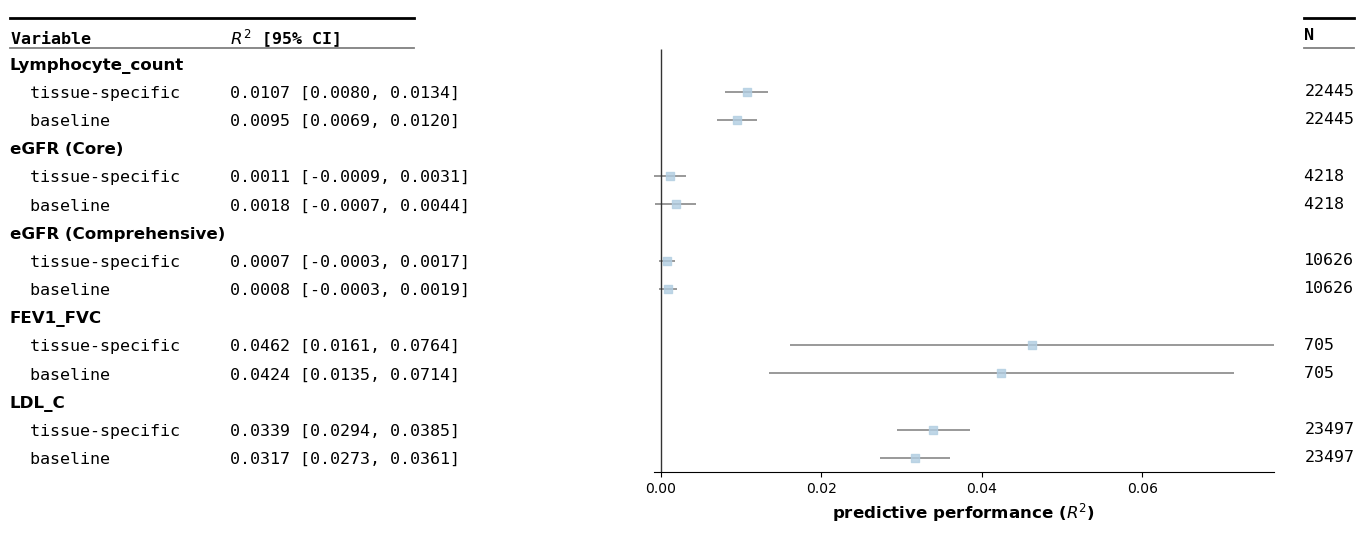

In [43]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

plot_df = input_df.copy()

cohort_order = ['Lymphocyte_count', 'eGFR (Core)', 'eGFR (Comprehensive)', 'FEV1_FVC', 'LDL_C']
    
plot_df['cohort'] = pd.Categorical(plot_df['trait'], categories=cohort_order, ordered=True)
    
plot_df = plot_df.sort_values(by=['cohort', 'n'], ascending=[True, False])

ax = fp.forestplot(
    plot_df,
    estimate="eval",
    ll="l_eval",
    hl="u_eval",
    varlabel="model",
    groupvar="cohort",
    annote=["r2_ci"],
    annoteheaders=[r"$R^{2}$ [95% CI]"],
    rightannote=["n_fmt"],
    right_annoteheaders=["N"],
    title="Forest Plot of Study Results",
    markercolor="#b1cde1",
    xlabel=r"predictive performance ($R^{2}$)",
    figsize=(8, 6), table=True
)
#ax.set_xlim(left=0)

plt.savefig(f'../main_meta_forest_log.pdf', bbox_inches='tight')